In [2]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from train import run_optimized_pipeline

c:\Users\imich\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
test_df, wf_predictions, best_params = run_optimized_pipeline(
    file_path="SPY_VIX_daily_clean.parquet",
    n_trials=10,
    n_splits=4
)

1. Fitting Static GARCH(1,1) Baseline...
2. Prepping Tensor Data for Optuna...
3. The Thunderdome (Running 10 Trials to find Architecture)...
--> Architecture Locked: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1541168988591605, 'lr': 0.00778936896513396}
4. Executing Rolling Window Walk-Forward Validation (4 Eras)...
   -> Inducing Amnesia and Training Era 1/4...
   -> Inducing Amnesia and Training Era 2/4...
   -> Inducing Amnesia and Training Era 3/4...
   -> Inducing Amnesia and Training Era 4/4...


In [ ]:
actual_vol = test_df['realized_vol'].values
dates = test_df.index
wf_rmse = np.sqrt(mean_squared_error(actual_vol, wf_predictions))

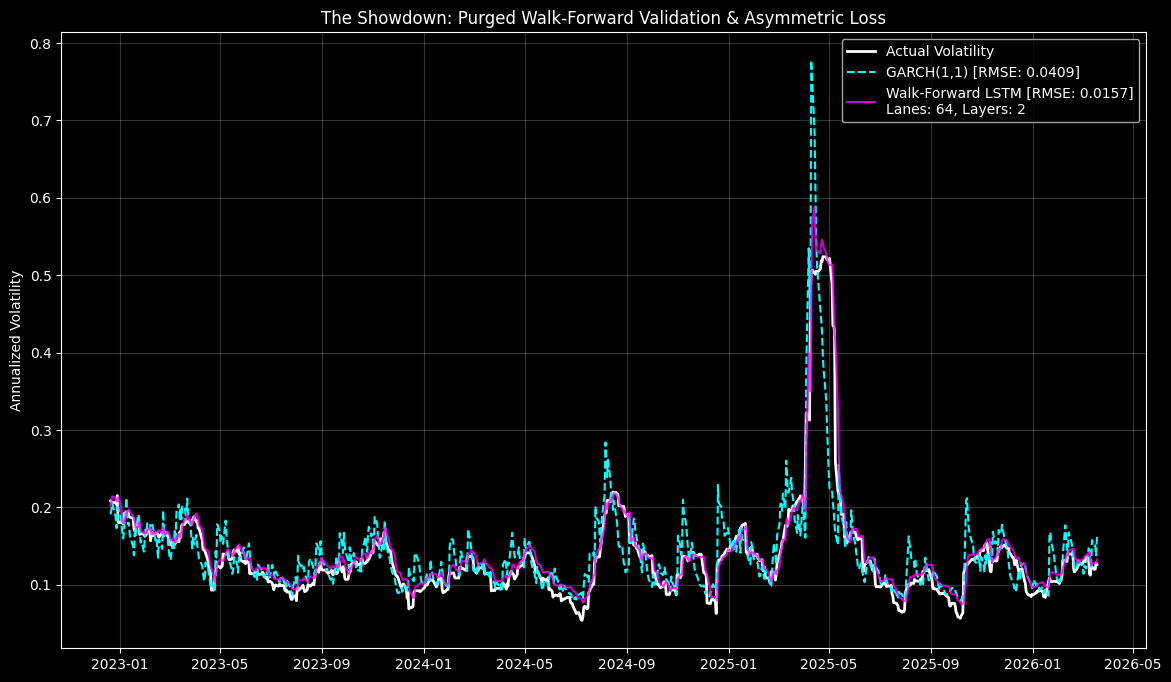

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(14, 8))
plt.plot(dates, actual_vol, label="Actual Volatility", color='white', linewidth=2)
plt.plot(dates, wf_predictions, label=f"Walk-Forward LSTM [RMSE: {wf_rmse:.4f}]\nLanes: {best_params['hidden_size']}, Layers: {best_params['num_layers']}", color='magenta', alpha=0.8)

plt.title("The Showdown: Purged Walk-Forward Validation & Asymmetric Loss")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.2)
plt.show()